In [ ]:

import os
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("andradaolteanu/gtzan-dataset-music-genre-classification")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'gtzan-dataset-music-genre-classification' dataset.
Path to dataset files: /kaggle/input/gtzan-dataset-music-genre-classification


In [ ]:

base_path = "/kaggle/input/gtzan-dataset-music-genre-classification"

for root, dirs, files in os.walk(base_path):
    print(root)


/kaggle/input/gtzan-dataset-music-genre-classification
/kaggle/input/gtzan-dataset-music-genre-classification/Data
/kaggle/input/gtzan-dataset-music-genre-classification/Data/images_original
/kaggle/input/gtzan-dataset-music-genre-classification/Data/images_original/disco
/kaggle/input/gtzan-dataset-music-genre-classification/Data/images_original/metal
/kaggle/input/gtzan-dataset-music-genre-classification/Data/images_original/reggae
/kaggle/input/gtzan-dataset-music-genre-classification/Data/images_original/blues
/kaggle/input/gtzan-dataset-music-genre-classification/Data/images_original/rock
/kaggle/input/gtzan-dataset-music-genre-classification/Data/images_original/classical
/kaggle/input/gtzan-dataset-music-genre-classification/Data/images_original/jazz
/kaggle/input/gtzan-dataset-music-genre-classification/Data/images_original/hiphop
/kaggle/input/gtzan-dataset-music-genre-classification/Data/images_original/country
/kaggle/input/gtzan-dataset-music-genre-classification/Data/image

In [ ]:
AUDIO_DIR = "/kaggle/input/gtzan-dataset-music-genre-classification/Data/genres_original"



In [ ]:
from tqdm import tqdm
import os
import librosa
import numpy as np
import pandas as pd

AUDIO_DIR = "/kaggle/input/gtzan-dataset-music-genre-classification/Data/genres_original"

features = []
labels = []

for genre in os.listdir(AUDIO_DIR):
    genre_path = os.path.join(AUDIO_DIR, genre)
    if not os.path.isdir(genre_path):
        continue

    print(f"Processing {genre}...")
    for file in tqdm(os.listdir(genre_path), desc=f"Processing {genre}"):
        file_path = os.path.join(genre_path, file)
        try:
            y, sr = librosa.load(file_path, sr=22050, duration=30)
            mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
            mfcc_mean = np.mean(mfcc.T, axis=0)
            features.append(mfcc_mean)
            labels.append(genre)
        except Exception as e:
            print("Skipped:", file_path)
            continue

df = pd.DataFrame(features)
df['label'] = labels

print("Done! Shape:", df.shape)
df.head()


Processing disco...


Processing disco: 100%|██████████| 100/100 [00:19<00:00,  5.07it/s]


Processing metal...


Processing metal: 100%|██████████| 100/100 [00:07<00:00, 13.50it/s]


Processing reggae...


...

Processing country: 100%|██████████| 100/100 [00:07<00:00, 13.12it/s]


Processing pop...


Processing pop: 100%|██████████| 100/100 [00:06<00:00, 15.38it/s]


Done! Shape: (999, 14)


,0,1,2,3,4,5,6,7,8,9,10,11,12,label
0,-66.568810,58.310627,-8.179027,15.493417,5.575189,7.697163,4.071543,-3.583531,-1.321885,1.608826,-5.482533,-3.734550,-3.239859,disco
1,-114.932060,113.463867,-29.804312,42.612103,-10.326010,26.973412,-14.493735,21.240530,-17.650539,17.097872,-13.478901,8.591482,-11.427423,disco
2,-154.623306,97.932602,-10.357319,39.123669,-11.213964,24.111309,-11.846502,24.191231,-13.460304,20.553188,-8.327632,5.867451,-9.686904,disco
3,-40.729240,63.947403,4.904890,16.340809,12.100068,9.339082,4.540618,5.189633,-0.589437,-0.069852,2.954615,-1.482167,-1.759873,disco
4,-121.095238,116.942505,-22.786968,45.148933,-4.239051,30.256325,-12.245273,21.729876,-16.540764,16.233280,-10.655168,7.330420,-9.353950,disco


In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split


In [ ]:

X = df.drop('label', axis=1).values
y = pd.factorize(df['label'])[0]



In [ ]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split( X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)



In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
print(" Data ready for training!")
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

 Data ready for training!
Training samples: 799
Testing samples: 200


In [ ]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score



In [ ]:
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)

rf_model.fit(X_train_scaled, y_train)

y_pred = rf_model.predict(X_test_scaled)

acc_rf = accuracy_score(y_test, y_pred)

In [ ]:
print(f"Random Forest Accuracy: {acc_rf:.2f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=[str(c) for c in le.classes_]))



Random Forest Accuracy: 0.64

Classification Report:
               precision    recall  f1-score   support

           0       0.43      0.50      0.47        20
           1       0.65      0.85      0.74        20
           2       0.67      0.60      0.63        20
           3       0.92      0.55      0.69        20
           4       0.82      0.45      0.58        20
           5       0.79      0.95      0.86        20
           6       0.56      0.70      0.62        20
           7       0.50      0.55      0.52        20
           8       0.58      0.55      0.56        20
           9       0.70      0.70      0.70        20

    accuracy                           0.64       200
   macro avg       0.66      0.64      0.64       200
weighted avg       0.66      0.64      0.64       200



In [ ]:
import librosa.display
import matplotlib.pyplot as plt





In [ ]:
SPECTROGRAM_DIR = "./spectrograms"
os.makedirs(SPECTROGRAM_DIR, exist_ok=True)

for genre in os.listdir(AUDIO_DIR):
    genre_path = os.path.join(AUDIO_DIR, genre)
    output_genre_dir = os.path.join(SPECTROGRAM_DIR, genre)
    os.makedirs(output_genre_dir, exist_ok=True)

    for file in tqdm(os.listdir(genre_path), desc=f"Creating spectrograms for {genre}"):
        file_path = os.path.join(genre_path, file)
        try:
            y, sr = librosa.load(file_path, sr=22050, duration=30)
            mel_spec = librosa.feature.melspectrogram(y=y, sr=sr)
            mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

            plt.figure(figsize=(2.24, 2.24))
            plt.axis("off")
            librosa.display.specshow(mel_spec_db, sr=sr, cmap='magma')
            save_path = os.path.join(output_genre_dir, file.replace(".wav", ".png"))
            plt.savefig(save_path, bbox_inches='tight', pad_inches=0)
            plt.close()
        except Exception as e:
            print("Skipped:", file_path)
            continue


Creating spectrograms for jazz:  26%|██▌       | 26/100 [00:07<00:20,  3.57it/s]/tmp/ipython-input-48397093.py:12: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(file_path, sr=22050, duration=30)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
Creating spectrograms for jazz:  27%|██▋       | 27/100 [00:07<00:18,  3.92it/s]

Skipped: /kaggle/input/gtzan-dataset-music-genre-classification/Data/genres_original/jazz/jazz.00054.wav


Creating spectrograms for pop: 100%|██████████| 100/100 [00:30<00:00,  3.31it/s]


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam



In [ ]:
datagen = ImageDataGenerator(validation_split=0.2, rescale=1./255)



In [ ]:
train_data = datagen.flow_from_directory(SPECTROGRAM_DIR,target_size=(224, 224),batch_size=16, class_mode='categorical', subset='training', shuffle=True)


Found 800 images belonging to 10 classes.


In [ ]:
datagen = ImageDataGenerator(
    rescale=1./255,rotation_range=25,width_shift_range=0.2,
    height_shift_range=0.2, zoom_range=0.3,brightness_range=[0.8, 1.2],horizontal_flip=True,validation_split=0.2)



In [ ]:
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = True




9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
for layer in base_model.layers[:-50]:
    layer.trainable = False



In [ ]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.4)(x)
preds = Dense(train_data.num_classes, activation='softmax')(x)


In [ ]:
cnn_model = Model(inputs=base_model.input, outputs=preds)



In [ ]:
cnn_model.compile(optimizer=Adam(learning_rate=0.0001),loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
cnn_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 1,867,914 (7.13 MB)

 Non-trainable params: 402,880 (1.54 MB)

In [ ]:
val_data = datagen.flow_from_directory(
    SPECTROGRAM_DIR,
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)


Found 199 images belonging to 10 classes.


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

callbacks = [
    EarlyStopping(patience=10, restore_best_weights=True, monitor='val_loss'),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=5, min_lr=1e-6)
]
layers.Dropout(0.3)

history = cnn_model.fit(
    train_data,
    validation_data=val_data,
    epochs=100,
    callbacks=callbacks
)


Epoch 1/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 160ms/step - accuracy: 0.8549 - loss: 0.5234 - val_accuracy: 0.2211 - val_loss: 2.3055 - learning_rate: 9.0000e-06
Epoch 2/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 137ms/step - accuracy: 0.8282 - loss: 0.5426 - val_accuracy: 0.2211 - val_loss: 2.2444 - learning_rate: 9.0000e-06
Epoch 3/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - accuracy: 0.8808 - loss: 0.4898 - val_accuracy: 0.1960 - val_loss: 2.2415 - learning_rate: 9.0000e-06
Epoch 4/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 109ms/step - accuracy: 0.8726 - loss: 0.4731 - val_accuracy: 0.1809 - val_loss: 2.3367 - learning_rate: 9.0000e-06
Epoch 5/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - accuracy: 0.8823 - loss: 0.4248 - val_accuracy: 0.1960 - val_loss: 2.2875 - learning_rate: 9.0000e-06
Epoch 6/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 111ms/step - accuracy: 0.9165 - loss: 0.4233 - val_accuracy: 0.2462 - val_loss: 2.2146 - learning_rate: 9.0000e-06
Epoch 7/100
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 88ms/step - accura

In [ ]:
acc_cnn = max(history.history['val_accuracy'])
print(f" Random Forest Accuracy (Tabular Features): {acc_rf:.3f}")
print(f"CNN Validation Accuracy (Spectrogram Images): {acc_cnn:.3f}")

if acc_cnn > acc_rf:
    print("\n CNN (Image-based) performed better.")
else:
    print("\n Random Forest (Tabular MFCC features) performed better.")


 Random Forest Accuracy (Tabular Features): 0.640
CNN Validation Accuracy (Spectrogram Images): 0.367

 Random Forest (Tabular MFCC features) performed better.


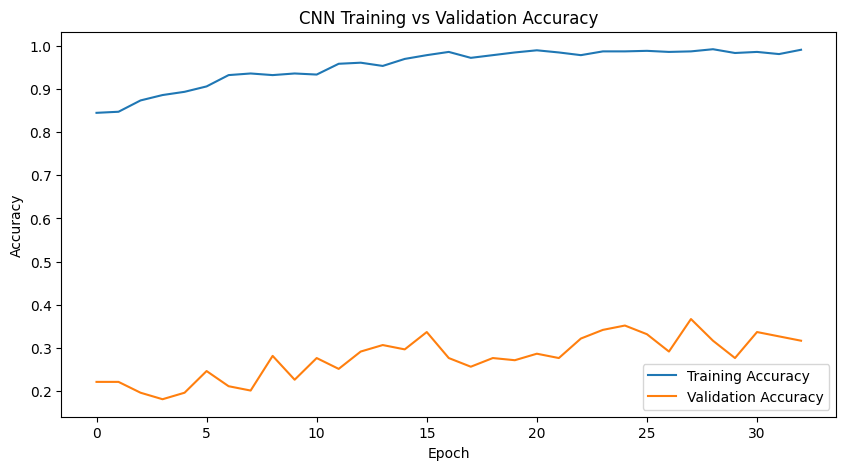

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


In [ ]:
 #Final Report

- **Dataset:** GTZAN Music Genre Classification
- **Models used:**
  1. Random Forest (on MFCC tabular features)
  2. CNN (MobileNetV2 on spectrogram images)
- **Results:**
  - Random Forest Accuracy: 0.64
  - CNN Validation Accuracy: 0.37
- **Conclusion:**
  The Random Forest model performed better on the MFCC-based tabular features compared to the CNN trained on spectrogram images.
  This could be due to the limited dataset size or insufficient fine-tuning of the CNN layers.
